---
date: "2026-09-13"
date-modified: last-modified
format:
  html:
    toc: true
---


# Vector Space (Linear Space)

::: {#def-vector-space}
## Vector Space (Linear Space)

A non-empty set $E$ is called a **vector space** (or **linear space**) over a [field](field.ipynb) $K$ if two operations — **addition** and **scalar multiplication** — are defined on it satisfying the axioms below.

### I\. Addition: $(E, +)$ is an Abelian Group

There exists an operation $+: E \times E \to E$ under which $E$ forms a **commutative (abelian) group**. That is, for all $u, v, w \in E$:

1. **Associativity**: $(u + v) + w = u + (v + w)$
2. **Commutativity**: $u + v = v + u$
3. **Additive identity**: $\exists\, 0 \in E$ such that $u + 0 = u$
4. **Additive inverse**: $\forall\, u \in E,\; \exists\, (-u) \in E$ such that $u + (-u) = 0$

### II\. Scalar Multiplication

For every $c \in K$ and every $u \in E$, an element $cu \in E$ is defined, satisfying:

1. **Compatibility of scalar multiplication** (mixed associativity):
   $$(kk')u = k(k'u), \qquad \forall\, k,k' \in K,\; u \in E$$
2. **Scalar identity**:
   $$1 \cdot u = u, \qquad \forall\, u \in E$$
3. **Distributivity of scalars over vector addition**:
   $$k(u + v) = ku + kv, \qquad \forall\, k \in K,\; u,v \in E$$
4. **Distributivity of vectors over scalar addition**:
   $$(k + k')u = ku + k'u, \qquad \forall\, k,k' \in K,\; u \in E$$

Elements of $K$ are called **scalars** and elements of $E$ are called **vectors**.
:::

::: {.callout-warning}
## Notation Overlap
The symbols $+$ and $\cdot$ are overloaded: the $+$ in axiom II.4 on the left-hand side is addition in $K$, while the $+$ on the right-hand side is addition in $E$. Similarly, $\cdot$ in II.1 on the left refers to multiplication in $K$, while $\cdot$ on the right denotes scalar multiplication. Context always disambiguates.
:::


## 1\. Examples of Vector Spaces

### 1\.1\. The Coordinate Space $K^n$

Let $K$ be a [field](field.ipynb). The set of all ordered $n$-tuples

$$K^n = \{(k_1, \dots, k_n) \mid k_i \in K\}$$

is a vector space over $K$ with component-wise operations:

$$
\begin{aligned}
(k_1,\dots,k_n) + (k'_1,\dots,k'_n) &= (k_1+k'_1,\;\dots,\;k_n+k'_n) \\
c\,(k_1,\dots,k_n) &= (ck_1,\;\dots,\;ck_n)
\end{aligned}
$$

When $K = \mathbb{R}$ and $n = 2$ or $3$, this recovers the familiar geometric vectors: addition corresponds to the parallelogram law, and multiplication by a negative scalar reverses direction.

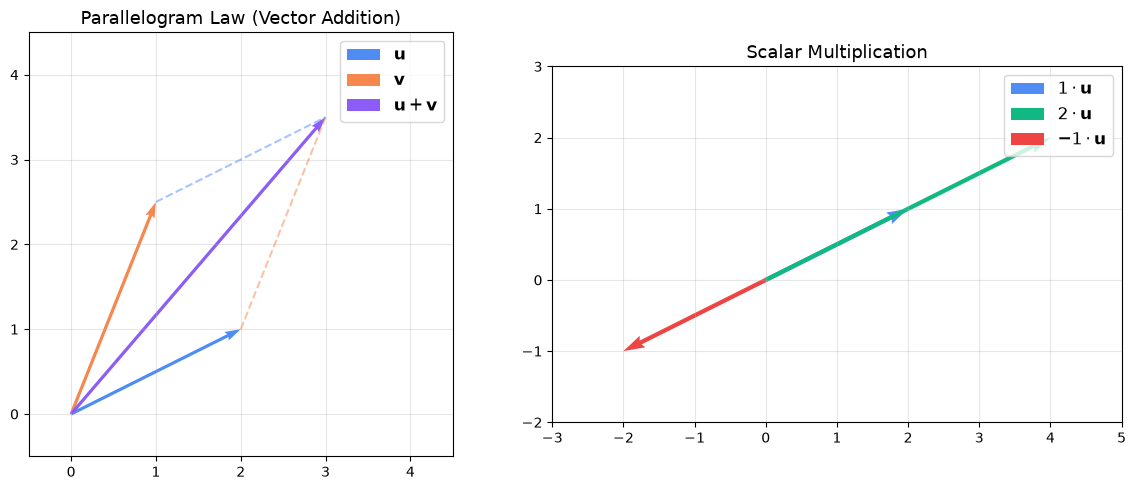

In [1]:

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left panel: parallelogram law ---
ax = axes[0]
u = np.array([2, 1])
v = np.array([1, 2.5])
w = u + v

ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1,
          color='#4f8df5', linewidth=2, label=r'$\mathbf{u}$')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='#f5874f', linewidth=2, label=r'$\mathbf{v}$')
ax.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1,
          color='#8b5cf6', linewidth=2.5, label=r'$\mathbf{u}+\mathbf{v}$')

# dashed parallelogram sides
ax.plot([u[0], w[0]], [u[1], w[1]], '--', color='#f5874f', alpha=0.5)
ax.plot([v[0], w[0]], [v[1], w[1]], '--', color='#4f8df5', alpha=0.5)

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_title('Parallelogram Law (Vector Addition)', fontsize=13)

# --- Right panel: scalar multiplication ---
ax = axes[1]
u = np.array([2, 1])
scalars = [1, 2, -1]
colors = ['#4f8df5', '#10b981', '#ef4444']
labels = [r'$1 \cdot \mathbf{u}$', r'$2 \cdot \mathbf{u}$', r'$-1 \cdot \mathbf{u}$']

for c, col, lab in zip(scalars, colors, labels):
    ax.quiver(0, 0, c*u[0], c*u[1], angles='xy', scale_units='xy', scale=1,
              color=col, linewidth=2, label=lab)

ax.set_xlim(-3, 5)
ax.set_ylim(-2, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_title('Scalar Multiplication', fontsize=13)

plt.tight_layout()
plt.show()


### 1\.2\. Function Spaces

Let $X$ be an arbitrary set and $K$ a [field](field.ipynb). The set of all functions from $X$ to $K$,

$$E = \{f \mid f: X \to K\},$$

is a vector space over $K$ with point-wise operations:

$$
\begin{aligned}
(f + g)(x) &= f(x) + g(x) \\
(cf)(x) &= c \cdot f(x)
\end{aligned}
$$

These are well-defined because $f(x)$ and $c$ both live in $K$, so their product and sum are computed using the field operations of $K$.

::: {.callout-note}
## $K^n$ as a Special Case of Function Spaces
Take $X = \{1, 2, \dots, n\}$. A function $f: X \to K$ is completely determined by its values $f(1), f(2), \dots, f(n)$, which is just an ordered $n$-tuple $(k_1, \dots, k_n)$ with $k_i = f(i)$. Therefore $K^n$ is precisely the space of functions from $\{1,\dots,n\}$ to $K$.

If the domain is a continuous interval $[a,b] \subseteq \mathbb{R}$, the resulting function space can be thought of as an "infinite-dimensional" analogue of $\mathbb{R}^n$.
:::


### 1\.3\. Polynomial Spaces

The set of polynomials with real coefficients of degree at most $p$,

$$P_p = \{a_0 + a_1 x + \cdots + a_p x^p \mid a_i \in \mathbb{R}\},$$

is a vector space over $\mathbb{R}$ with the natural operations:

- **Addition**: coefficients are added component-wise.
- **Scalar multiplication**: each coefficient is multiplied by the scalar.

The map $(a_0, a_1, \dots, a_p) \mapsto a_0 + a_1 x + \cdots + a_p x^p$ establishes a natural structural correspondence (an [isomorphism](#def-linear-isomorphism)) between $P_p$ and $\mathbb{R}^{p+1}$.

Similarly, the set of **all** polynomials with real coefficients (of any degree) also forms a vector space over $\mathbb{R}$.


### 1\.4\. Continuous, Differentiable, and Integrable Functions

The following sets are all vector spaces over $\mathbb{R}$:

- The set of **continuous** functions on $[a,b]$, denoted $C([a,b])$.
- The set of **differentiable** functions on $[a,b]$.
- The set of **integrable** functions on $[a,b]$.

In each case, the vector space structure follows because the relevant class of functions is closed under point-wise addition and scalar multiplication:

- The sum of two continuous functions is continuous.
- A scalar multiple of a continuous function is continuous.
- The same closure properties hold for differentiable and integrable functions.


### 1\.5\. Solution Space of a Homogeneous Linear ODE

Consider the second-order homogeneous [ODE](ordinary-differential-equations.html) of the harmonic oscillator:

$$\frac{d^2 x}{dt^2} + \omega^2 x = 0$$

Let $S$ be the set of all twice-differentiable functions $f$ satisfying this equation. Then $S$ is a **vector space** over $\mathbb{R}$.

::: {.callout-tip collapse="true"}
## Proof: $S$ is Closed Under Addition and Scalar Multiplication

**Closure under addition.** If $f$ and $g$ are both solutions, then

$$
\begin{aligned}
(f+g)'' + \omega^2(f+g) &= (f'' + g'') + \omega^2 f + \omega^2 g \\
&= \bigl(f'' + \omega^2 f\bigr) + \bigl(g'' + \omega^2 g\bigr) \\
&= 0 + 0 = 0
\end{aligned}
$$

**Closure under scalar multiplication.** For any $c \in \mathbb{R}$,

$$
(cf)'' + \omega^2(cf) = c\bigl(f'' + \omega^2 f\bigr) = c \cdot 0 = 0
$$

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Structural Resemblance to $\mathbb{R}^2$
From physics (or ODE theory), every solution is uniquely determined by two initial conditions $f(0)$ and $f'(0)$. The map $f \mapsto (f(0),\, f'(0))$ gives a bijection between the solution space and $\mathbb{R}^2$, so the solution space is structurally identical (isomorphic) to $\mathbb{R}^2$.
:::

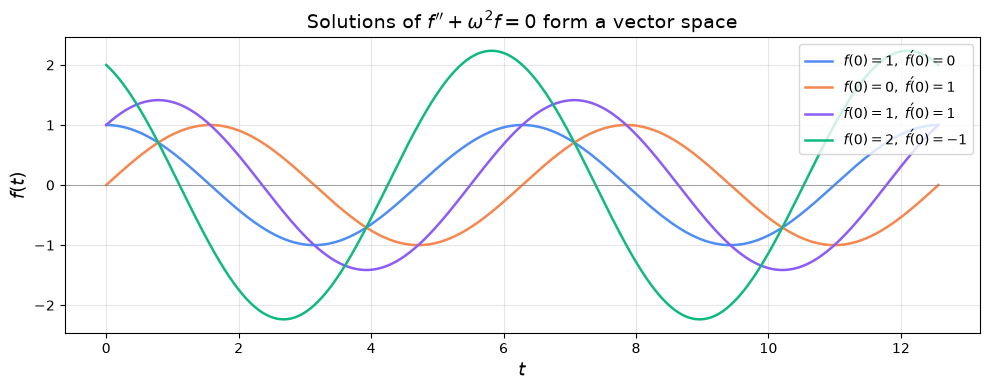

In [2]:

import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 4 * np.pi, 500)
omega = 1.0

# several solutions from different initial conditions
initial_conditions = [
    (1, 0, r'$f(0)=1,\; f\'(0)=0$'),
    (0, 1, r'$f(0)=0,\; f\'(0)=1$'),
    (1, 1, r'$f(0)=1,\; f\'(0)=1$'),
    (2, -1, r'$f(0)=2,\; f\'(0)=-1$'),
]

colors = ['#4f8df5', '#f5874f', '#8b5cf6', '#10b981']

fig, ax = plt.subplots(figsize=(10, 4))
for (x0, v0, lab), col in zip(initial_conditions, colors):
    # general solution: x0 cos(wt) + (v0/w) sin(wt)
    f = x0 * np.cos(omega * t) + (v0 / omega) * np.sin(omega * t)
    ax.plot(t, f, color=col, linewidth=1.8, label=lab)

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('$t$', fontsize=13)
ax.set_ylabel('$f(t)$', fontsize=13)
ax.set_title(r"Solutions of $f'' + \omega^2 f = 0$ form a vector space", fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2\. Subspaces

::: {#def-subspace}
## Linear Subspace

Let $E$ be a vector space over a [field](field.ipynb) $K$. A subset $F \subseteq E$ is called a **linear subspace** (or simply **subspace**) of $E$ if $F$, equipped with the addition and scalar multiplication inherited from $E$, is itself a vector space over $K$.
:::

---

::: {#prp-subspace-criterion}
## Subspace Criterion

A subset $F \subseteq E$ is a subspace if and only if it is **closed** under the inherited operations:

1. $u + v \in F \quad \forall\, u,v \in F$
2. $cu \in F \quad \forall\, c \in K,\; u \in F$
:::

::: {.callout-tip collapse="true"}
## Proof of @prp-subspace-criterion

**($\Rightarrow$)** If $F$ is a subspace then it is a vector space in its own right, so it must be closed under its operations.

**($\Leftarrow$)** Assume closure. The algebraic properties — associativity, commutativity, distributivity — are inherited automatically from the ambient space $E$ because they hold for *all* elements of $E$ and hence for elements in $F \subseteq E$.

It remains to show $F$ contains the zero vector and additive inverses:

- **Zero vector:** Pick any $u \in F$ (possible since $F$ is non-empty by the subspace definition). By closure under scalar multiplication, $0 \cdot u = 0 \in F$.
- **Additive inverse:** For any $u \in F$, $(-1) \cdot u = -u \in F$.

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Subspaces Pass Through the Origin
In $\mathbb{R}^n$, subspaces are lines, planes, and hyper-planes that **always pass through the origin**. A plane that does not pass through $0$ is *not* a subspace (it lacks the zero vector).
:::

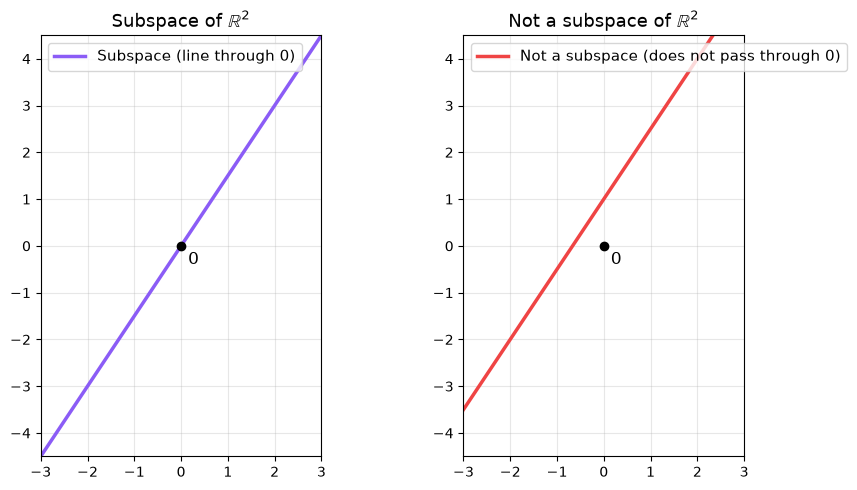

In [3]:

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))

# --- Left: subspace (line through origin) ---
ax1 = fig.add_subplot(121)
t = np.linspace(-3, 3, 100)
ax1.plot(t, 1.5 * t, color='#8b5cf6', linewidth=2.5, label='Subspace (line through $0$)')
ax1.plot(0, 0, 'ko', markersize=6, zorder=5)
ax1.annotate('$0$', (0.15, -0.4), fontsize=12)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-4.5, 4.5)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_title('Subspace of $\\mathbb{R}^2$', fontsize=13)

# --- Right: NOT a subspace (shifted line) ---
ax2 = fig.add_subplot(122)
ax2.plot(t, 1.5 * t + 1, color='#ef4444', linewidth=2.5, label='Not a subspace (does not pass through $0$)')
ax2.plot(0, 0, 'ko', markersize=6, zorder=5)
ax2.annotate('$0$', (0.15, -0.4), fontsize=12)
ax2.set_xlim(-3, 3)
ax2.set_ylim(-4.5, 4.5)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11, loc='upper left')
ax2.set_title('Not a subspace of $\\mathbb{R}^2$', fontsize=13)

plt.tight_layout()
plt.show()


## 3\. Isomorphism of Vector Spaces

::: {#def-linear-isomorphism}
## Linear Isomorphism

Let $E$ and $E'$ be two vector spaces over the same [field](field.ipynb) $K$. A mapping $\alpha: E \to E'$ is called a **linear isomorphism** if:

1. $\alpha$ is **bijective** (one-to-one and onto),
2. $\alpha$ **preserves addition**:
   $$\alpha(u + v) = \alpha(u) + \alpha(v), \qquad \forall\, u,v \in E$$
3. $\alpha$ **preserves scalar multiplication**:
   $$\alpha(cu) = c\,\alpha(u), \qquad \forall\, c \in K,\; u \in E$$

If such a map exists, we say $E$ and $E'$ are **isomorphic** and write $E \cong E'$.
:::

::: {.callout-note}
## Intuition: Same Structure, Different Labels
An isomorphism means that the two spaces are algebraically *identical* — they have exactly the same vector-space structure — and differ only in the names or nature of their elements. For instance, the space of degree-$\le 1$ polynomials $\{a + bx\}$ is isomorphic to $\mathbb{R}^2$ via $a + bx \mapsto (a, b)$, and the solution space of a second-order linear ODE is isomorphic to $\mathbb{R}^2$ via $f \mapsto (f(0), f'(0))$.

All finite-dimensional vector spaces of the same dimension over $K$ behave identically to $K^n$.
:::